# Forecasting the FIFA World Cup 2026 — a probabilistic, validated model

This notebook estimates every team's probability of reaching each round of the 2026 World Cup, and of winning it,with a transparent, fully reproducible statistical pipeline. It runs end to end with **no setup**: open in Colab and choose *Runtime → Run all*.

## Method

The forecast is built in three stages:

1. **Team strength (Elo).** Ratings are computed from scratch over ~50,000 historical international matches (1872-present), with importance weights, a goal-margin factor, and home advantage.
2. **Match model (Dixon-Coles bivariate Poisson).** The Elo gap between two teams is mapped to a full *scoreline* distribution, not just win/draw/loss,because the group stage is ranked on goal difference. The four parameters are fit by maximum likelihood on the modern era, using each match's *pre-kickoff* ratings to avoid look-ahead.
3. **Tournament simulation (Monte Carlo).** The real 2026 bracket 12 groups → 8 best third-placed teams → Round of 32 → Final, including FIFA's slot-allocation rules is simulated 50,000 times, turning match-level uncertainty into tournament-level probabilities.

## Beyond a single prediction

- **Out-of-sample calibration.** The model is back-tested on thousands of matches it never saw (log-loss, Brier score, accuracy, and a reliability curve), so the probabilities are *checked*, not assumed.
- **Sensitivity analysis.** Each team's title odds are attributed to causes through counterfactual re-simulations (e.g. how much comes from the team's own strength versus the draw).
- **Scenario analysis.** Force a hypothetical result and re-estimate the whole field.
- **Living forecast.** Pin matches as they are played (real scorelines and knockout winners) and the probabilities update toward the realised outcome.

## Data & reproducibility

Team strength is computed live from public international results (`martj42/international_results`). An optional path uses a Kaggle dataset for ratings, and a built-in ratings snapshot keeps the notebook fully runnable offline. All randomness is seeded, so results are deterministic.

**Stack:** Python · NumPy · SciPy · pandas · Matplotlib.

> Forecasts are illustrative. A short knockout tournament carries large irreducible variance; quantifying that uncertainty honestly is the point of the exercise.
>

### Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Ready — run the cells top to bottom.")

Ready — run the cells top to bottom.


## 1 · Tournament structure
The real 2026 groups (A-L), the three hosts, and the full Round-of-32 → Final bracket
(matches 73-104), including FIFA's third-place slot-eligibility rules.

In [2]:
"""
The real FIFA World Cup 2026 tournament structure.

Everything in this module is sourced from the official Final Draw
(Washington D.C., 5 December 2025) and the resolved March 2026 play-offs:
the 12 groups (A-L), the three host nations, and the complete
Round-of-32 -> Final knockout tree (matches 73-104), including the
"best eight third-placed teams" slot-eligibility rules that are unique
to the 48-team format.

Team names use the convention of the historical results dataset
(martj42/international_results) so that Elo ratings join cleanly.
`DISPLAY` maps them to their broadcast names for pretty output.
"""

# ---------------------------------------------------------------------------
# Groups (positions are just the drawn order; standings are computed by sim)
# ---------------------------------------------------------------------------
GROUPS: dict[str, list[str]] = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}

GROUP_LETTERS = list(GROUPS.keys())
ALL_TEAMS = [t for g in GROUPS.values() for t in g]

# Co-hosts play (most of) their matches at home -> a real, measurable edge.
# We fold this into team strength as a fixed Elo bonus (see config).
HOSTS = {"United States", "Mexico", "Canada"}

# Broadcast / friendly display names
DISPLAY = {
    "South Korea": "Korea Rep.",
    "Czech Republic": "Czechia",
    "Turkey": "Türkiye",
    "United States": "USA",
    "Bosnia and Herzegovina": "Bosnia & H.",
    "Ivory Coast": "Côte d'Ivoire",
    "Cape Verde": "Cabo Verde",
}


def disp(team: str) -> str:
    return DISPLAY.get(team, team)


# ---------------------------------------------------------------------------
# Round of 32 (matches 73-88).
# Each slot is (group_letter, position): position 1 = winner, 2 = runner-up.
# Third-placed slots are special: the group is unknown until the group
# stage finishes, so they reference one of the eight THIRD_SLOTS below.
# ---------------------------------------------------------------------------
# A fixed slot: ("G", pos).  A third slot: ("3RD", match_no).
R32 = [
    (73, ("A", 2), ("B", 2)),
    (74, ("E", 1), ("3RD", 74)),
    (75, ("F", 1), ("C", 2)),
    (76, ("C", 1), ("F", 2)),
    (77, ("I", 1), ("3RD", 77)),
    (78, ("E", 2), ("I", 2)),
    (79, ("A", 1), ("3RD", 79)),
    (80, ("L", 1), ("3RD", 80)),
    (81, ("D", 1), ("3RD", 81)),
    (82, ("G", 1), ("3RD", 82)),
    (83, ("K", 2), ("L", 2)),
    (84, ("H", 1), ("J", 2)),
    (85, ("B", 1), ("3RD", 85)),
    (86, ("J", 1), ("H", 2)),
    (87, ("K", 1), ("3RD", 87)),
    (88, ("D", 2), ("G", 2)),
]

# The eight third-place slots and the groups each is allowed to draw from.
# (Official FIFA eligibility table for the 2026 bracket.)
THIRD_SLOTS = {
    74: set("ABCDF"),
    77: set("CDFGH"),
    79: set("CEFHI"),
    80: set("EHIJK"),
    81: set("BEFIJ"),
    82: set("AEHIJ"),
    85: set("EFGIJ"),
    87: set("DEIJL"),
}
THIRD_SLOT_ORDER = [74, 77, 79, 80, 81, 82, 85, 87]

# ---------------------------------------------------------------------------
# The rest of the tree: (match_no, feeder_a, feeder_b) where feeders are the
# winners of earlier matches.  104 is the Final; 103 (3rd-place) is omitted.
# ---------------------------------------------------------------------------
KO_TREE = [
    # Round of 16
    (89, 74, 77), (90, 73, 75), (91, 76, 78), (92, 79, 80),
    (93, 83, 84), (94, 81, 82), (95, 86, 88), (96, 85, 87),
    # Quarter-finals
    (97, 89, 90), (98, 93, 94), (99, 91, 92), (100, 95, 96),
    # Semi-finals
    (101, 97, 98), (102, 99, 100),
    # Final
    (104, 101, 102),
]

# Stage labels, used for reporting how far each team is expected to go.
STAGES = ["Round of 32", "Round of 16", "Quarter-final", "Semi-final", "Final", "Champion"]


def sanity_check() -> None:
    """Validate the bracket is internally consistent (run in tests)."""
    assert len(ALL_TEAMS) == 48, "expected 48 teams"
    assert len(set(ALL_TEAMS)) == 48, "duplicate team in draw"
    assert len(R32) == 16
    # every winner & runner-up appears exactly once across R32
    winners = [s for _, a, b in R32 for s in (a, b) if s[0] != "3RD" and s[1] == 1]
    runners = [s for _, a, b in R32 for s in (a, b) if s[0] != "3RD" and s[1] == 2]
    assert sorted(w[0] for w in winners) == GROUP_LETTERS, "winners mismatch"
    assert sorted(r[0] for r in runners) == GROUP_LETTERS, "runners mismatch"
    assert len(THIRD_SLOTS) == 8 and len(THIRD_SLOT_ORDER) == 8
    # KO tree feeds resolve
    produced = {m for m, _, _ in R32} | {m for m, _, _ in KO_TREE}
    for _, a, b in KO_TREE:
        assert a in produced and b in produced, f"dangling feeder {a},{b}"

# expose the constants above under a single namespace `D`, used by later cells
import types
D = types.SimpleNamespace(
    GROUPS=GROUPS, GROUP_LETTERS=GROUP_LETTERS, ALL_TEAMS=ALL_TEAMS, HOSTS=HOSTS,
    DISPLAY=DISPLAY, disp=disp, R32=R32, THIRD_SLOTS=THIRD_SLOTS,
    THIRD_SLOT_ORDER=THIRD_SLOT_ORDER, KO_TREE=KO_TREE, STAGES=STAGES,
)
sanity_check()
print(len(ALL_TEAMS), "teams,", len(GROUPS), "groups — bracket OK")

48 teams, 12 groups — bracket OK


## 2 · Strength engine - Elo
Ratings computed from scratch over the full history of internationals (eloratings.net
rules: importance-weighted, goal-margin-scaled, home advantage). `attach_prematch_elo`
tags each match with the ratings held *before* kick-off, so the goal model is fit
without look-ahead.

In [3]:
"""
World-football Elo ratings, computed from scratch on the full history of
international matches (1872 -> present).

Why Elo? It compresses everything that matters about a national team -- form,
squad quality, the strength of opponents it has actually beaten -- into a
single auditable number, and updates it after every match. It is famously hard
to beat as a *single* feature, and unlike a black-box rating we can recompute
it ourselves and see exactly where it comes from.

The implementation follows the well-known eloratings.net rules:
  * K depends on match importance (friendlies count less than World Cups);
  * the goal margin inflates the update (a 4-0 win moves Elo more than 1-0);
  * home advantage is added before computing the expected result.
"""

import numpy as np
import pandas as pd

# Match-importance weights (eloratings.net style).
TOURNAMENT_K = {
    "FIFA World Cup": 60,
    "FIFA World Cup qualification": 40,
    "Copa América": 50,
    "UEFA Euro": 50,
    "UEFA Euro qualification": 40,
    "African Cup of Nations": 40,
    "AFC Asian Cup": 40,
    "Gold Cup": 40,
    "CONCACAF Championship": 40,
    "UEFA Nations League": 40,
    "Confederations Cup": 45,
    "Friendly": 20,
}
DEFAULT_K = 30          # any tournament not listed above
HOME_ADV = 65.0         # Elo points added to the home side
BASE_RATING = 1500.0


def _k_factor(tournament: str, goal_diff: int) -> float:
    base = TOURNAMENT_K.get(tournament, DEFAULT_K)
    # Goal-difference multiplier (eloratings.net).
    if goal_diff <= 1:
        mult = 1.0
    elif goal_diff == 2:
        mult = 1.5
    else:
        mult = (11 + goal_diff) / 8.0
    return base * mult


def compute_elo(
    results: pd.DataFrame,
    *,
    base: float = BASE_RATING,
    home_adv: float = HOME_ADV,
    as_of: str | None = None,
    return_history: bool = False,
):
    """
    Run Elo over the match history and return final ratings.

    Parameters
    ----------
    results : DataFrame with columns
        date, home_team, away_team, home_score, away_score, tournament, neutral
    as_of : optional ISO date; only matches strictly before it are used
        (essential for backtesting -- never peek at the future).
    return_history : if True, also return a list of (date, ratings_snapshot).

    Returns
    -------
    dict[str, float]  team -> Elo rating   (and optionally the history list)
    """
    df = results.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.dropna(subset=["home_score", "away_score"])
    if as_of is not None:
        df = df[df["date"] < pd.to_datetime(as_of)]
    df = df.sort_values("date")

    ratings: dict[str, float] = {}
    history = []

    home = df["home_team"].to_numpy()
    away = df["away_team"].to_numpy()
    hs = df["home_score"].to_numpy()
    as_ = df["away_score"].to_numpy()
    neu = (df["neutral"].astype(str).str.upper() == "TRUE").to_numpy()
    trn = df["tournament"].to_numpy()
    dts = df["date"].to_numpy()

    for i in range(len(df)):
        h, a = home[i], away[i]
        rh = ratings.get(h, base)
        ra = ratings.get(a, base)

        adv = 0.0 if neu[i] else home_adv
        exp_h = 1.0 / (1.0 + 10 ** (-((rh + adv) - ra) / 400.0))

        gd = int(hs[i] - as_[i])
        if gd > 0:
            score_h = 1.0
        elif gd < 0:
            score_h = 0.0
        else:
            score_h = 0.5

        k = _k_factor(str(trn[i]), abs(gd))
        delta = k * (score_h - exp_h)
        ratings[h] = rh + delta
        ratings[a] = ra - delta

        if return_history and i % 500 == 0:
            history.append((dts[i], dict(ratings)))

    if return_history:
        return ratings, history
    return ratings


def attach_prematch_elo(
    results: pd.DataFrame, *, base: float = BASE_RATING, home_adv: float = HOME_ADV
) -> pd.DataFrame:
    """
    Replay Elo and tag every *played* match with the ratings the two teams
    held *before* kick-off.  These look-ahead-free ratings are what the goal
    model is fit on, so the fitted rating->goals mapping is honest.
    """
    df = results.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.dropna(subset=["home_score", "away_score"]).sort_values("date").reset_index(drop=True)

    ratings: dict[str, float] = {}
    eh = np.empty(len(df))
    ea = np.empty(len(df))
    home = df["home_team"].to_numpy()
    away = df["away_team"].to_numpy()
    hs = df["home_score"].to_numpy()
    as_ = df["away_score"].to_numpy()
    neu = (df["neutral"].astype(str).str.upper() == "TRUE").to_numpy()
    trn = df["tournament"].to_numpy()

    for i in range(len(df)):
        h, a = home[i], away[i]
        rh = ratings.get(h, base)
        ra = ratings.get(a, base)
        eh[i] = rh
        ea[i] = ra
        adv = 0.0 if neu[i] else home_adv
        exp_h = 1.0 / (1.0 + 10 ** (-((rh + adv) - ra) / 400.0))
        gd = int(hs[i] - as_[i])
        score_h = 1.0 if gd > 0 else (0.0 if gd < 0 else 0.5)
        k = _k_factor(str(trn[i]), abs(gd))
        delta = k * (score_h - exp_h)
        ratings[h] = rh + delta
        ratings[a] = ra - delta

    df["elo_home_pre"] = eh
    df["elo_away_pre"] = ea
    return df


def ratings_table(ratings: dict[str, float], teams: list[str] | None = None) -> pd.DataFrame:
    """Tidy DataFrame of ratings, optionally restricted to a team list."""
    items = ratings.items() if teams is None else [(t, ratings.get(t, BASE_RATING)) for t in teams]
    out = (
        pd.DataFrame(items, columns=["team", "elo"])
        .sort_values("elo", ascending=False)
        .reset_index(drop=True)
    )
    return out

## 3 · Match model - Dixon-Coles bivariate Poisson
Predicts a full *scoreline* distribution (you need goal difference for the group
ranking). Four parameters fit by maximum likelihood; defaults below are the fitted
values, so the model is sensible even before any fitting.

In [4]:
"""
The match engine: a Dixon-Coles bivariate Poisson model.

Most hobby predictors stop at a single win/draw/loss probability. That throws
away the thing the 2026 group format actually ranks teams on -- *goal
difference*. So instead we model a full scoreline distribution for any pairing.

For two teams with Elo ratings r_h and r_a we set
    log(lambda_home) = c + b * d + gamma * home
    log(lambda_away) = c - b * d                       , d = (r_h - r_a) / 100
and the joint probability of the score (x, y) is
    tau(x, y) * Poisson(x; lambda_home) * Poisson(y; lambda_away)
where tau is the Dixon-Coles low-score correction that fixes independent
Poisson's well-known under-prediction of 0-0 / 1-1 draws (governed by rho).

The four parameters (c, b, gamma, rho) are fit by maximum likelihood on
historical internationals, using each match's *pre-kick-off* Elo gap.
"""

from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson

MAX_GOALS = 10  # scoreline grid is 0..MAX_GOALS for each side


def _dc_tau(x, y, lam, mu, rho):
    """Dixon-Coles low-score adjustment (vectorised over scorelines)."""
    t = np.ones_like(lam, dtype=float)
    t = np.where((x == 0) & (y == 0), 1.0 - lam * mu * rho, t)
    t = np.where((x == 0) & (y == 1), 1.0 + lam * rho, t)
    t = np.where((x == 1) & (y == 0), 1.0 + mu * rho, t)
    t = np.where((x == 1) & (y == 1), 1.0 - rho, t)
    return t


@dataclass
class MatchModel:
    """A fitted (or default) rating->goals model."""

    c: float = 0.0968       # base log scoring rate (~1.17 goals/side at parity)
    b: float = 0.1883       # how strongly a 100-Elo edge lifts expected goals
    gamma: float = 0.2410   # home-advantage bump in log-goals (non-neutral only)
    rho: float = -0.0440    # Dixon-Coles draw correction
    elo_scale: float = 100.0
    fitted_on: int = 0    # number of matches used to fit (0 = library defaults)

    # ---- expected goals -------------------------------------------------
    def lambdas(self, elo_h, elo_a, home=False):
        d = (np.asarray(elo_h) - np.asarray(elo_a)) / self.elo_scale
        adv = self.gamma if home else 0.0
        lam_h = np.exp(self.c + self.b * d + adv)
        lam_a = np.exp(self.c - self.b * d)
        return lam_h, lam_a

    # ---- full scoreline matrix for one fixture --------------------------
    def scoreline_matrix(self, elo_h, elo_a, home=False) -> np.ndarray:
        lam_h, lam_a = self.lambdas(elo_h, elo_a, home)
        gh = np.arange(MAX_GOALS + 1)
        ph = poisson.pmf(gh, float(lam_h))
        pa = poisson.pmf(gh, float(lam_a))
        m = np.outer(ph, pa)
        xx, yy = np.meshgrid(gh, gh, indexing="ij")
        m = m * _dc_tau(xx, yy, float(lam_h), float(lam_a), self.rho)
        return m / m.sum()

    # ---- win / draw / loss ---------------------------------------------
    def outcome_probs(self, elo_h, elo_a, home=False):
        m = self.scoreline_matrix(elo_h, elo_a, home)
        p_home = np.tril(m, -1).sum()
        p_draw = np.trace(m)
        p_away = np.triu(m, 1).sum()
        return float(p_home), float(p_draw), float(p_away)

    def most_likely_score(self, elo_h, elo_a, home=False):
        m = self.scoreline_matrix(elo_h, elo_a, home)
        i, j = np.unravel_index(m.argmax(), m.shape)
        return int(i), int(j)

    # ---- fitting --------------------------------------------------------
    @classmethod
    def fit(cls, matches: pd.DataFrame, *, since: str = "2010-01-01", verbose: bool = False):
        """
        Maximum-likelihood fit on matches that already carry pre-match Elo
        (see elo.attach_prematch_elo). `since` restricts to the modern era so
        the scoring rate reflects today's game.
        """
        df = matches.copy()
        df["date"] = pd.to_datetime(df["date"])
        df = df[df["date"] >= pd.to_datetime(since)]
        df = df.dropna(subset=["home_score", "away_score", "elo_home_pre", "elo_away_pre"])

        x = df["home_score"].to_numpy().astype(int)
        y = df["away_score"].to_numpy().astype(int)
        x = np.clip(x, 0, MAX_GOALS)
        y = np.clip(y, 0, MAX_GOALS)
        d = (df["elo_home_pre"].to_numpy() - df["elo_away_pre"].to_numpy()) / 100.0
        home = (df["neutral"].astype(str).str.upper() != "TRUE").to_numpy().astype(float)

        def neg_ll(theta):
            c, b, gamma, rho = theta
            rho = np.clip(rho, -0.2, 0.2)
            lam = np.exp(c + b * d + gamma * home)
            mu = np.exp(c - b * d)
            lam = np.clip(lam, 1e-6, 30)
            mu = np.clip(mu, 1e-6, 30)
            ll = poisson.logpmf(x, lam) + poisson.logpmf(y, mu)
            tau = _dc_tau(x, y, lam, mu, rho)
            ll = ll + np.log(np.clip(tau, 1e-9, None))
            return -ll.sum()

        res = minimize(neg_ll, x0=[0.16, 0.34, 0.30, -0.08], method="Nelder-Mead",
                       options={"maxiter": 4000, "xatol": 1e-5, "fatol": 1e-4})
        c, b, gamma, rho = res.x
        model = cls(c=float(c), b=float(b), gamma=float(gamma),
                    rho=float(np.clip(rho, -0.2, 0.2)), fitted_on=len(df))
        if verbose:
            print(f"Fitted on {len(df):,} matches  ->  "
                  f"c={model.c:.3f} b={model.b:.3f} gamma={model.gamma:.3f} rho={model.rho:.3f}")
        return model

    def to_dict(self):
        return {"c": self.c, "b": self.b, "gamma": self.gamma, "rho": self.rho,
                "elo_scale": self.elo_scale, "fitted_on": self.fitted_on}

## 4 · Tournament engine - Vectorized Monte Carlo
Simulates the whole tournament tens of thousands of times in seconds: group round-robins
with tiebreakers, the eight best third-placed teams slotted by bipartite matching, then
the knockout tree with an Elo-weighted extra-time/penalty decider.

In [5]:
"""
The tournament engine: a fully vectorised Monte Carlo simulation of the
entire 2026 World Cup, from the 72 group matches through the 31 knockout ties
to the Final -- run tens of thousands of times in a couple of seconds.

For each simulated tournament we:
  1. play every group's round-robin and rank teams by points, then goal
     difference, then goals scored (ties broken by lots);
  2. pick the eight best third-placed teams across all 12 groups;
  3. slot those thirds into the Round of 32 respecting FIFA's eligibility
     table (matched by a constraint solver, since the slot a third lands in
     depends on *which* groups the eight thirds came from);
  4. play the knockout tree (draws after 90' resolved by an Elo-weighted
     extra-time / penalty model);
  5. tally how far every team got.

Aggregating over all runs turns one uncertain model into clean probabilities:
each team's chance of winning the group, reaching each round, and lifting
the trophy.
"""

from functools import lru_cache

import numpy as np
import pandas as pd


# round-robin pairings for a 4-team group (indices into the group's team list)
_GROUP_PAIRS = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

# allow overrides/queries to use friendly names ("Türkiye") or canonical ("Turkey")
_DISPLAY_TO_CANON = {v: k for k, v in D.DISPLAY.items()}


def _canon_team(name: str) -> str:
    if name in D.ALL_TEAMS:
        return name
    return _DISPLAY_TO_CANON.get(name, name)


# ---------------------------------------------------------------------------
# Third-place slot allocation (Kuhn's bipartite matching, memoised per combo)
# ---------------------------------------------------------------------------
@lru_cache(maxsize=None)
def _match_thirds(groups: tuple[str, ...]) -> tuple[str, ...] | None:
    """Assign the 8 qualifying third-place groups to the 8 R32 slots.

    Returns groups ordered to match D.THIRD_SLOT_ORDER, or None if no
    eligibility-respecting assignment exists (does not occur for FIFA's table).
    """
    slots = D.THIRD_SLOT_ORDER
    elig = [D.THIRD_SLOTS[s] for s in slots]
    match_for_slot: dict[int, str] = {}

    def try_assign(si: int, seen: set[str]) -> bool:
        for g in sorted(groups):
            if g in elig[si] and g not in seen:
                seen.add(g)
                # is g free, or can its current holder move elsewhere?
                holder = next((k for k, v in match_for_slot.items() if v == g), None)
                if holder is None or try_assign(_slot_pos(holder), seen):
                    match_for_slot[slots[si]] = g
                    return True
        return False

    def _slot_pos(slot_no: int) -> int:
        return slots.index(slot_no)

    for i in range(len(slots)):
        if not try_assign(i, set()):
            return None
    return tuple(match_for_slot[s] for s in slots)


class Tournament:
    """A configured 2026 World Cup ready to be simulated."""

    def __init__(self, elo: dict[str, float], model: MatchModel | None = None,
                 *, host_bonus: float = 60.0, seed: int = 0):
        self.model = model or MatchModel()
        self.teams = list(D.ALL_TEAMS)
        self.idx = {t: i for i, t in enumerate(self.teams)}
        self.host_bonus = host_bonus
        self.seed = seed
        # team strength array, with the host edge folded in
        self.elo = np.array(
            [elo.get(t, 1500.0) + (host_bonus if t in D.HOSTS else 0.0) for t in self.teams],
            dtype=float,
        )
        # group -> array of 4 team indices
        self.group_idx = {g: np.array([self.idx[t] for t in members])
                          for g, members in D.GROUPS.items()}

    # -- one knockout tie, vectorised over all simulations -----------------
    def _play(self, a_idx, b_idx, rng):
        ea, eb = self.elo[a_idx], self.elo[b_idx]
        lam_a, lam_b = self.model.lambdas(ea, eb, home=False)
        ga = rng.poisson(lam_a)
        gb = rng.poisson(lam_b)
        a_win = ga > gb
        b_win = gb > ga
        draw = ~(a_win | b_win)
        # extra time + penalties: stronger team favoured but heavily damped
        p_a = 1.0 / (1.0 + 10 ** (-(ea - eb) / 800.0))
        coin = rng.random(len(a_idx)) < p_a
        a_through = a_win | (draw & coin)
        return np.where(a_through, a_idx, b_idx)

    # -- main entry point --------------------------------------------------
    def simulate(self, n_sims: int = 50_000, *, group_match_overrides: dict | None = None,
                 ko_overrides: dict | None = None, seed: int | None = None) -> pd.DataFrame:
        rng = np.random.default_rng(self.seed if seed is None else seed)
        n = n_sims
        overrides = self._normalise_overrides(group_match_overrides or {})
        # decided knockout ties: {match_no: winning team index}, broadcast to all sims
        ko_fixed = {int(m): self.idx[_canon_team(t)] for m, t in (ko_overrides or {}).items()}

        # ---- group stage --------------------------------------------------
        win_idx, run_idx = {}, {}                    # group -> team-idx array
        third_idx = np.empty((12, n), dtype=np.int64)
        third_key = np.empty((12, n), dtype=float)   # for ranking thirds across groups

        for gi, (g, members) in enumerate(D.GROUPS.items()):
            tidx = self.group_idx[g]
            pts = np.zeros((4, n)); gf = np.zeros((4, n)); ga = np.zeros((4, n))
            for (i, j) in _GROUP_PAIRS:
                ei, ej = self.elo[tidx[i]], self.elo[tidx[j]]
                li, lj = self.model.lambdas(ei, ej, home=False)
                gi_, gj_ = rng.poisson(li, n), rng.poisson(lj, n)
                ov = overrides.get((g, i, j))
                if ov is not None:
                    gi_, gj_ = self._forced_goals(ov, n)
                home_w, away_w = gi_ > gj_, gj_ > gi_
                draw = ~(home_w | away_w)
                pts[i] += np.where(home_w, 3, np.where(draw, 1, 0))
                pts[j] += np.where(away_w, 3, np.where(draw, 1, 0))
                gf[i] += gi_; ga[i] += gj_
                gf[j] += gj_; ga[j] += gi_
            gd = gf - ga
            rand = rng.random((4, n))
            # strict lexicographic key: points > goal diff > goals for > lots
            key = pts * 1e12 + (gd + 50) * 1e8 + gf * 1e4 + rand
            order = np.argsort(-key, axis=0)          # rank 0 = group winner
            rows = np.arange(n)
            w = tidx[order[0]]; r = tidx[order[1]]; t = tidx[order[2]]
            win_idx[g], run_idx[g] = w, r
            third_idx[gi] = t
            third_key[gi] = pts[order[2], rows] * 1e12 + (gd[order[2], rows] + 50) * 1e8 \
                + gf[order[2], rows] * 1e4 + rng.random(n)

        # ---- best 8 third-placed teams ------------------------------------
        third_order = np.argsort(-third_key, axis=0)          # rank groups' thirds
        qual_groups = third_order[:8]                         # (8, n) group indices
        qual_mask = np.zeros((12, n), dtype=bool)
        qual_mask[qual_groups, np.arange(n)] = True
        slot_team = self._allocate_thirds(qual_mask, third_idx, n)  # dict slot_no -> idx array

        # ---- knockout stage ----------------------------------------------
        def resolve(side):
            if side[0] == "3RD":
                return slot_team[side[1]]
            g, pos = side
            return win_idx[g] if pos == 1 else run_idx[g]

        winners: dict[int, np.ndarray] = {}
        for m, a, b in D.R32:
            a_idx, b_idx = resolve(a), resolve(b)
            w = self._play(a_idx, b_idx, rng)
            if m in ko_fixed:                      # a decided tie: pin the winner,
                t = ko_fixed[m]                    # but only where that team actually plays
                w = np.where((a_idx == t) | (b_idx == t), t, w)
            winners[m] = w
        for m, fa, fb in D.KO_TREE:
            a_idx, b_idx = winners[fa], winners[fb]
            w = self._play(a_idx, b_idx, rng)
            if m in ko_fixed:
                t = ko_fixed[m]
                w = np.where((a_idx == t) | (b_idx == t), t, w)
            winners[m] = w

        # ---- tally --------------------------------------------------------
        def freq(arrs):
            cat = np.concatenate(arrs) if isinstance(arrs, list) else arrs
            return np.bincount(cat, minlength=48) / n

        champ = freq(winners[104])
        final = freq([winners[101], winners[102]])
        semi = freq([winners[m] for m in (97, 98, 99, 100)])
        quarter = freq([winners[m] for m in range(89, 97)])
        r16 = freq([winners[m] for m in range(73, 89)])
        qualifiers = [win_idx[g] for g in D.GROUPS] + [run_idx[g] for g in D.GROUPS] \
            + [slot_team[s] for s in D.THIRD_SLOT_ORDER]
        r32 = freq(qualifiers)
        win_group = freq([win_idx[g] for g in D.GROUPS])
        top2 = freq([win_idx[g] for g in D.GROUPS] + [run_idx[g] for g in D.GROUPS])

        df = pd.DataFrame({
            "team": [D.disp(t) for t in self.teams],
            "group": [next(g for g, mm in D.GROUPS.items() if t in mm) for t in self.teams],
            "elo": np.round(self.elo, 0).astype(int),
            "win_group": win_group,
            "advance": top2,
            "reach_R16": r16,
            "reach_QF": quarter,
            "reach_SF": semi,
            "reach_final": final,
            "champion": champ,
        }).sort_values("champion", ascending=False).reset_index(drop=True)
        df.attrs["n_sims"] = n
        return df

    # -- helpers -----------------------------------------------------------
    def _allocate_thirds(self, qual_mask, third_idx, n):
        weights = (1 << np.arange(12)).astype(np.int64)
        masks = (qual_mask.T.astype(np.int64) * weights).sum(axis=1)   # (n,)
        uniq, inv = np.unique(masks, return_inverse=True)
        order = D.THIRD_SLOT_ORDER
        assign = np.zeros((len(uniq), 8), dtype=np.int64)
        for k, mk in enumerate(uniq):
            groups = tuple(D.GROUP_LETTERS[g] for g in range(12) if (mk >> g) & 1)
            res = _match_thirds(groups)
            if res is None:                       # extremely rare / never for FIFA table
                res = self._greedy_thirds(groups)
            assign[k] = [D.GROUP_LETTERS.index(g) for g in res]
        rows = np.arange(n)
        slot_team = {}
        for p, slot_no in enumerate(order):
            gidx = assign[inv, p]                 # group index feeding this slot, per sim
            slot_team[slot_no] = third_idx[gidx, rows]
        return slot_team

    @staticmethod
    def _greedy_thirds(groups):
        avail = set(groups); out = {}
        for s in sorted(D.THIRD_SLOT_ORDER, key=lambda s: len(D.THIRD_SLOTS[s] & avail)):
            cand = sorted(D.THIRD_SLOTS[s] & avail) or sorted(avail)
            out[s] = cand[0]; avail.discard(cand[0])
        return tuple(out[s] for s in D.THIRD_SLOT_ORDER)

    def _normalise_overrides(self, ov):
        """Translate {(group, teamA, teamB): result} -> {(group, i, j): (gi, gj)}.

        `result` is the string teamA / teamB / "draw" (a placeholder 1-0 / 1-1),
        or a real scoreline tuple (goalsA, goalsB) — preferred once a match is
        actually played, because group ranking depends on goal difference.
        """
        out = {}
        for (g, a, b), result in ov.items():
            members = D.GROUPS[g]
            a, b = _canon_team(a), _canon_team(b)
            ia, ib = members.index(a), members.index(b)
            swap = ia > ib
            i, j = (ib, ia) if swap else (ia, ib)
            if isinstance(result, (tuple, list)):
                ga, gb = int(result[0]), int(result[1])     # teamA goals, teamB goals
            elif result == "draw":
                ga, gb = 1, 1
            elif result == a:
                ga, gb = 1, 0
            else:
                ga, gb = 0, 1
            out[(g, i, j)] = (gb, ga) if swap else (ga, gb)  # orient to slot (i, j)
        return out

    @staticmethod
    def _forced_goals(score, n):
        gi, gj = score
        return np.full(n, gi, dtype=int), np.full(n, gj, dtype=int)


def forecast_from_state(elo: dict, model: MatchModel | None = None, *,
                        group_scores: dict | None = None, ko_winners: dict | None = None,
                        n_sims: int = 50_000, host_bonus: float = 60.0,
                        seed: int = 0) -> pd.DataFrame:
    """A *living* forecast: pin matches that have already been played and
    simulate only the rest.

    Parameters
    ----------
    group_scores : {(group_letter, teamA, teamB): (goalsA, goalsB)}
        Real results of group matches already played, e.g.
        {("C", "Brazil", "Scotland"): (3, 1)}. Use the real scoreline so the
        group's goal-difference tiebreaker is correct. (A W/D/L string also
        works but assumes a 1-0 / 1-1 placeholder.)
    ko_winners : {match_no: winning_team}
        Decided knockout ties, e.g. {84: "Spain", 73: "Switzerland"}.
        Match numbers: 73-88 Round of 32, 89-96 Round of 16, 97-100 quarter-
        finals, 101-102 semi-finals, 104 final.

    Team names may be canonical or broadcast spellings. Returns the same tidy
    probability table as Tournament.simulate, now conditioned on what has
    actually happened. As more results are pinned, the odds sharpen toward 0/1.
    """
    tour = Tournament(elo, model, host_bonus=host_bonus, seed=seed)
    return tour.simulate(n_sims, group_match_overrides=group_scores or {},
                         ko_overrides=ko_winners or {}, seed=seed)

## 5 · Calibration, explainability, what-if & plots
Validation and analysis layers: calibration, sensitivity analysis, scenarios, and plots.

In [6]:
"""
Calibration & backtesting.

A forecast is only worth trusting if its probabilities are *honest*: when it
says 70%, that thing should happen about 70% of the time. This module replays
recent history as an out-of-sample test -- fit the model on matches before a
cut-off, then score its predictions on every international played since -- and
reports the metrics that matter for probabilistic forecasts:

  * log-loss  (proper scoring rule; lower is better)
  * Brier score (mean squared probability error; lower is better)
  * accuracy (did the argmax outcome happen)
  * a skill score vs a naive base-rate model
  * a reliability table (predicted vs observed) for the calibration curve.
"""

import numpy as np
import pandas as pd


CLASSES = ("home", "draw", "away")


def _metrics(probs: np.ndarray, y: np.ndarray) -> dict:
    eps = 1e-12
    p = np.clip(probs, eps, 1.0)
    onehot = np.eye(3)[y]
    logloss = float(-np.mean(np.log(p[np.arange(len(y)), y])))
    brier = float(np.mean(((p - onehot) ** 2).sum(axis=1)))
    acc = float(np.mean(p.argmax(axis=1) == y))
    return {"log_loss": logloss, "brier": brier, "accuracy": acc, "n": int(len(y))}


def backtest(matches_with_elo: pd.DataFrame, *, cutoff: str = "2022-01-01",
             train_since: str = "2008-01-01") -> dict:
    """
    Walk-forward backtest. `matches_with_elo` must already carry leak-free
    pre-match Elo (elo.attach_prematch_elo); Elo itself only ever uses the
    past, so evaluating on post-cutoff matches is genuinely out-of-sample.
    """
    df = matches_with_elo.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.dropna(subset=["home_score", "away_score", "elo_home_pre", "elo_away_pre"])

    train = df[(df["date"] >= train_since) & (df["date"] < cutoff)]
    test = df[df["date"] >= cutoff]

    model = MatchModel.fit(train, since=train_since)

    # outcome label for each test match
    hs = test["home_score"].to_numpy()
    as_ = test["away_score"].to_numpy()
    y = np.where(hs > as_, 0, np.where(hs == as_, 1, 2))
    home_flag = (test["neutral"].astype(str).str.upper() != "TRUE").to_numpy()
    eh = test["elo_home_pre"].to_numpy()
    ea = test["elo_away_pre"].to_numpy()

    probs = np.array([model.outcome_probs(eh[i], ea[i], home=bool(home_flag[i]))
                      for i in range(len(test))])

    # naive baseline: training-set outcome frequencies, applied to every match
    base_rate = np.eye(3)[
        np.where(train["home_score"].to_numpy() > train["away_score"].to_numpy(), 0,
                 np.where(train["home_score"].to_numpy() == train["away_score"].to_numpy(), 1, 2))
    ].mean(axis=0)
    base_probs = np.tile(base_rate, (len(test), 1))

    m_model = _metrics(probs, y)
    m_base = _metrics(base_probs, y)
    skill = 1.0 - m_model["log_loss"] / m_base["log_loss"]

    # reliability curve on P(home win)
    p_home = probs[:, 0]
    bins = np.linspace(0, 1, 11)
    which = np.clip(np.digitize(p_home, bins) - 1, 0, 9)
    rel = []
    for k in range(10):
        sel = which == k
        if sel.sum() >= 10:
            rel.append({"bin": (bins[k] + bins[k + 1]) / 2,
                        "predicted": float(p_home[sel].mean()),
                        "observed": float((y[sel] == 0).mean()),
                        "n": int(sel.sum())})
    reliability = pd.DataFrame(rel)

    return {
        "model": model,
        "model_metrics": m_model,
        "baseline_metrics": m_base,
        "skill_score": float(skill),
        "reliability": reliability,
        "cutoff": cutoff,
    }


def summary_text(bt: dict) -> str:
    mm, bm = bt["model_metrics"], bt["baseline_metrics"]
    return (
        f"Out-of-sample backtest (matches since {bt['cutoff']}, n={mm['n']:,})\n"
        f"  log-loss : {mm['log_loss']:.4f}  (baseline {bm['log_loss']:.4f})\n"
        f"  Brier    : {mm['brier']:.4f}  (baseline {bm['brier']:.4f})\n"
        f"  accuracy : {mm['accuracy']*100:.1f}%  (baseline {bm['accuracy']*100:.1f}%)\n"
        f"  skill vs baseline (log-loss): {bt['skill_score']*100:.1f}%"
    )

In [7]:
"""
Explainability: *why* does the model rate a team the way it does?

Black-box predictors hand you a number. We instead probe the model with
counterfactuals -- re-running the whole tournament with one thing changed --
to attribute a team's title odds to concrete, legible causes:

  * Strength      : how much of the odds is the team's own Elo worth, versus
                    an exactly-average side dropped into the same group/bracket?
  * Field         : how much comes from the rest of the field being beatable
                    (others set to average) -- i.e. an easy era vs a stacked one?
  * Sensitivity   : how do the odds move if the team were +50 / +100 / -100 Elo
                    (≈ a key injury, a hot streak, a new manager bounce)?

Each line is just another simulation, so nothing here is hand-waved.
"""

import numpy as np
import pandas as pd



def _champion_prob(elo: dict, model, team_disp: str, n_sims: int, host_bonus: float,
                   seed: int) -> float:
    df = Tournament(elo, model, host_bonus=host_bonus, seed=seed).simulate(n_sims, seed=seed)
    row = df.loc[df["team"] == team_disp, "champion"]
    return float(row.iloc[0]) if len(row) else 0.0


def explain_team(elo: dict, model: MatchModel | None, team: str, *,
                 n_sims: int = 20_000, host_bonus: float = 60.0, seed: int = 1) -> pd.DataFrame:
    """Return a tidy table of counterfactual title probabilities for `team`.

    `team` may be the canonical or display name.
    """
    model = model or MatchModel()
    # resolve to the canonical key used in `elo`
    canon = team
    if team not in elo:
        canon = next((t for t in D.ALL_TEAMS if D.disp(t) == team), team)
    disp = D.disp(canon)

    field_median = float(np.median([elo.get(t, 1500.0) for t in D.ALL_TEAMS]))

    scenarios = {
        "Actual forecast": dict(elo),
        "If team were average": {**elo, canon: field_median},
        "Team +50 Elo": {**elo, canon: elo.get(canon, 1500.0) + 50},
        "Team +100 Elo": {**elo, canon: elo.get(canon, 1500.0) + 100},
        "Team -100 Elo": {**elo, canon: elo.get(canon, 1500.0) - 100},
        "If field were average": {**{t: field_median for t in D.ALL_TEAMS}, canon: elo.get(canon, 1500.0)},
    }
    rows = []
    for label, e in scenarios.items():
        rows.append({"scenario": label,
                     "champion_pct": 100 * _champion_prob(e, model, disp, n_sims, host_bonus, seed)})
    out = pd.DataFrame(rows)
    base = out.loc[out["scenario"] == "Actual forecast", "champion_pct"].iloc[0]
    out["delta_vs_actual"] = out["champion_pct"] - base
    out.attrs["team"] = disp
    return out

In [9]:
"""
What-if scenario engine.

The forecast is a *distribution*, so we can ask conditional questions:
"if this result happened, how does everyone's title race change?" You force a
group result (a win or a draw), re-simulate the rest of the tournament, and
diff the title odds against the baseline. The biggest movers are usually not
the two teams on the pitch -- they are the rivals whose path just got easier
or harder, which is exactly the kind of second-order effect a single bracket
prediction can never show you.
"""

import pandas as pd



def what_if(elo: dict, model: MatchModel | None, base_df: pd.DataFrame,
            overrides: dict, *, n_sims: int = 30_000, host_bonus: float = 60.0,
            seed: int = 2) -> pd.DataFrame:
    """
    Re-run the tournament with `overrides` forced and return each team's new
    title odds plus the change from baseline.

    overrides : {(group_letter, teamA, teamB): result}
        result is one of teamA, teamB (winner) or the string "draw".
        Team names may be canonical or display names.
    base_df   : a baseline simulate() result to diff against.
    """
    model = model or MatchModel()
    tour = Tournament(elo, model, host_bonus=host_bonus, seed=seed)
    # map display names in overrides back to canonical group members
    fixed = {}
    for (g, a, b), res in overrides.items():
        canon = {D.disp(t): t for t in D.GROUPS[g]}
        ca = canon.get(a, a); cb = canon.get(b, b)
        cres = res if res == "draw" else canon.get(res, res)
        fixed[(g, ca, cb)] = cres

    new = tour.simulate(n_sims, group_match_overrides=fixed, seed=seed)
    merged = base_df[["team", "champion"]].merge(
        new[["team", "champion"]], on="team", suffixes=("_base", "_scenario"))
    merged["delta"] = merged["champion_scenario"] - merged["champion_base"]
    merged = merged.reindex(merged["delta"].abs().sort_values(ascending=False).index)
    return merged.reset_index(drop=True)


def force_match(elo, model, base_df, group, team_a, team_b, result, **kw):
    """Convenience wrapper for a single forced group result."""
    return what_if(elo, model, base_df, {(group, team_a, team_b): result}, **kw)

In [17]:
"""
Plotting helpers (matplotlib only -- no seaborn dependency).

Every figure is built from a simulate()/backtest()/explain() result, saved to
outputs/figures, and returned so notebooks can display it inline.
"""

import os

import matplotlib.pyplot as plt
import numpy as np

ACCENT = "#1f7a8c"
ACCENT2 = "#bf3100"
GRID = "#e6e6e6"


def _style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)


def _save(fig, path):
    if path:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        fig.savefig(path, dpi=600, bbox_inches="tight", facecolor="white")
    return fig


def bar_champion(df, top: int = 16, path: str | None = None):
    d = df.head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.42 * top + 1))
    ax.barh(d["team"], d["champion"] * 100, color=ACCENT, zorder=3)
    for y, v in enumerate(d["champion"] * 100):
        ax.text(v + 0.15, y, f"{v:.1f}%", va="center", fontsize=9, color="#333")
    _style(ax)
    ax.set_xlabel("Probability of winning the World Cup (%)")
    ax.set_title(f"FIFA World Cup 2026 — title odds (top {top})", fontweight="bold")
    return _save(fig, path)


def stage_heatmap(df, top: int = 20, path: str | None = None):
    cols = ["advance", "reach_R16", "reach_QF", "reach_SF", "reach_final", "champion"]
    labels = ["Advance", "R16", "QF", "SF", "Final", "Champion"]
    d = df.head(top)
    mat = d[cols].to_numpy() * 100
    fig, ax = plt.subplots(figsize=(7.5, 0.4 * top + 1.2))
    im = ax.imshow(mat, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(d)), d["team"])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    fontsize=8, color="white" if v > 55 else "#222")
    ax.set_title(f"How far each team goes — reach probability (%), top {top}",
                 fontweight="light")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="%")
    return _save(fig, path)


def reliability_plot(reliability, path: str | None = None):
    fig, ax = plt.subplots(figsize=(5.2, 5))
    ax.plot([0, 1], [0, 1], "--", color="#999", label="perfect calibration")
    if len(reliability):
        ax.plot(reliability["predicted"], reliability["observed"], "o-",
                color=ACCENT2, label="model", zorder=3)
        ax.scatter(reliability["predicted"], reliability["observed"],
                   s=reliability["n"] / reliability["n"].max() * 120 + 10,
                   color=ACCENT2, alpha=0.35, zorder=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted P(home win)")
    ax.set_ylabel("Observed frequency")
    ax.set_title("Calibration on held-out matches", fontweight="light")
    ax.legend(frameon=False)
    ax.set_aspect("equal")
    return _save(fig, path)


def explain_chart(explain_df, path: str | None = None):
    team = explain_df.attrs.get("team", "team")
    d = explain_df.set_index("scenario")["champion_pct"]
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    colors = [ACCENT if s == "Actual forecast" else "#9bbfc7" for s in d.index]
    ax.bar(range(len(d)), d.values, color=colors, zorder=3)
    ax.set_xticks(range(len(d)), d.index, rotation=20, ha="right", fontsize=8.5)
    for x, v in enumerate(d.values):
        ax.text(x, v + 0.2, f"{v:.1f}%", ha="center", fontsize=8.5)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_ylabel("Title probability (%)")
    ax.set_title(f"Why {team}? — counterfactual title odds", fontweight="light")
    return _save(fig, path)


def whatif_chart(delta_df, top: int = 10, path: str | None = None, title: str = "What-if"):
    d = delta_df.head(top).iloc[::-1]
    vals = d["delta"] * 100
    fig, ax = plt.subplots(figsize=(7.5, 0.42 * top + 1))
    ax.barh(d["team"], vals, color=[ACCENT2 if v < 0 else ACCENT for v in vals], zorder=3)
    ax.axvline(0, color="#666", lw=1)
    for y, v in enumerate(vals):
        ax.text(v + (0.05 if v >= 0 else -0.05), y, f"{v:+.1f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8.5)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_xlabel("Change in title probability (percentage points)")
    ax.set_title(title, fontweight="light")
    return _save(fig, path)

## 6 · Load the data → ratings + fitted model
Primary path: compute Elo from public match history and fit the model on it.
Optional: flip `USE_KAGGLE=True` (needs `pip install kagglehub` + Kaggle credentials) to
use the Kaggle dataset's ratings instead. Offline fallback is built in.

In [18]:
RESULTS_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
USE_KAGGLE = False   # set True if you have kagglehub + Kaggle credentials configured

NAME_FIX = {
    "Korea Republic": "South Korea", "Republic of Korea": "South Korea",
    "Czechia": "Czech Republic", "Türkiye": "Turkey", "Turkiye": "Turkey",
    "Côte d'Ivoire": "Ivory Coast", "Cote d'Ivoire": "Ivory Coast",
    "Cabo Verde": "Cape Verde", "USA": "United States",
    "United States of America": "United States", "IR Iran": "Iran",
    "Congo DR": "DR Congo", "Curacao": "Curaçao", "China PR": "China",
}
def canon(name): return NAME_FIX.get(str(name).strip(), str(name).strip())

# Built-in ratings snapshot (used only if the history fetch fails)
FALLBACK_ELO = { "Mexico": 1956.7, "South Africa": 1648.2, "South Korea": 1879.2, "Czech Republic": 1800.0, "Canada": 1888.6, "Bosnia and Herzegovina": 1645.7, "Qatar": 1574.0, "Switzerland": 1950.3, "Brazil": 2046.8, "Morocco": 1985.0, "Haiti": 1682.7, "Scotland": 1831.5, "United States": 1848.2, "Paraguay": 1901.1, "Australia": 1895.1, "Turkey": 1956.4, "Germany": 1999.6, "Curaçao": 1592.8, "Ivory Coast": 1811.6, "Ecuador": 2004.6, "Netherlands": 2002.2, "Japan": 1995.4, "Sweden": 1768.1, "Tunisia": 1752.0, "Belgium": 1939.1, "Egypt": 1796.0, "Iran": 1889.3, "New Zealand": 1719.3, "Spain": 2203.7, "Cape Verde": 1683.5, "Saudi Arabia": 1687.1, "Uruguay": 1956.6, "France": 2112.3, "Senegal": 1903.1, "Iraq": 1744.6, "Norway": 1968.6, "Argentina": 2168.7, "Algeria": 1864.0, "Austria": 1887.1, "Jordan": 1769.0, "Portugal": 2027.8, "DR Congo": 1757.8, "Uzbekistan": 1821.8, "Colombia": 2040.9, "England": 2076.2, "Croatia": 1957.7, "Ghana": 1635.7, "Panama": 1829.4 }

def kaggle_strength(frames):
    team_keys = ("team","country","nation","name","squad")
    rate_keys = ("elo","rating","power","strength","spi","score")
    best = None
    for df in frames.values():
        cols = {c.lower(): c for c in df.columns}
        tcol = next((cols[k] for k in cols if any(t in k for t in team_keys)), None)
        rcol = next((cols[k] for k in cols if any(r in k for r in rate_keys)), None)
        if tcol and rcol:
            m = {}
            for _, row in df[[tcol, rcol]].dropna().iterrows():
                try: m[canon(row[tcol])] = float(row[rcol])
                except (ValueError, TypeError): pass
            hits = sum(t in m for t in ALL_TEAMS)
            if best is None or hits > best[0]: best = (hits, m)
    if not best or best[0] < 40: return None
    return best[1]

def build_inputs(use_kaggle=False):
    try:
        hist = pd.read_csv(RESULTS_URL)
        elo_full = {canon(k): v for k, v in compute_elo(hist).items()}
        elo = {t: elo_full.get(t, 1500.0) for t in ALL_TEAMS}
        model = MatchModel.fit(attach_prematch_elo(hist), since="2010-01-01")
        n = hist.dropna(subset=["home_score"]).shape[0]
        note = f"Computed Elo from {n:,} historical internationals (martj42)."
    except Exception as e:
        print("History fetch failed (", type(e).__name__, ") — using built-in snapshot.")
        hist, elo, model = None, dict(FALLBACK_ELO), MatchModel()
        note = "Offline fallback: embedded Elo snapshot + pre-fitted match model."
    if use_kaggle:
        try:
            import kagglehub, glob, os
            path = kagglehub.dataset_download("pranishkessi/fifa-world-cup-2026-prediction-simulator")
            frames = {os.path.basename(f): pd.read_csv(f)
                      for f in glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)}
            ks = kaggle_strength(frames)
            if ks:
                elo = {t: ks.get(t, elo[t]) for t in ALL_TEAMS}
                note = "Kaggle dataset ratings (Elo fallback for gaps)."
        except Exception as e:
            print("Kaggle path unavailable (", type(e).__name__, ") — keeping:", note)
    return elo, model, hist, note

elo, model, results, source = build_inputs(USE_KAGGLE)
print("Ratings source:", source)
print("Match model   :", model.to_dict())
ratings_table(elo, teams=list(ALL_TEAMS)).assign(team=lambda d: d.team.map(disp)).head(12)

Ratings source: Computed Elo from 49,365 historical internationals (martj42).
Match model   : {'c': 0.09666569834683829, 'b': 0.18829035277520623, 'gamma': 0.24144025217818255, 'rho': -0.043893182076295285, 'elo_scale': 100.0, 'fitted_on': 15777}


,team,elo
0,Spain,2203.750421
1,Argentina,2170.428949
2,France,2112.297209
3,England,2078.447411
4,Brazil,2050.646240
5,Colombia,2040.889203
6,Portugal,2030.671380
7,Germany,2007.206476
8,Ecuador,2004.599141
9,Netherlands,2002.177728


## 7 · The forecast - 50,000 simulated tournaments

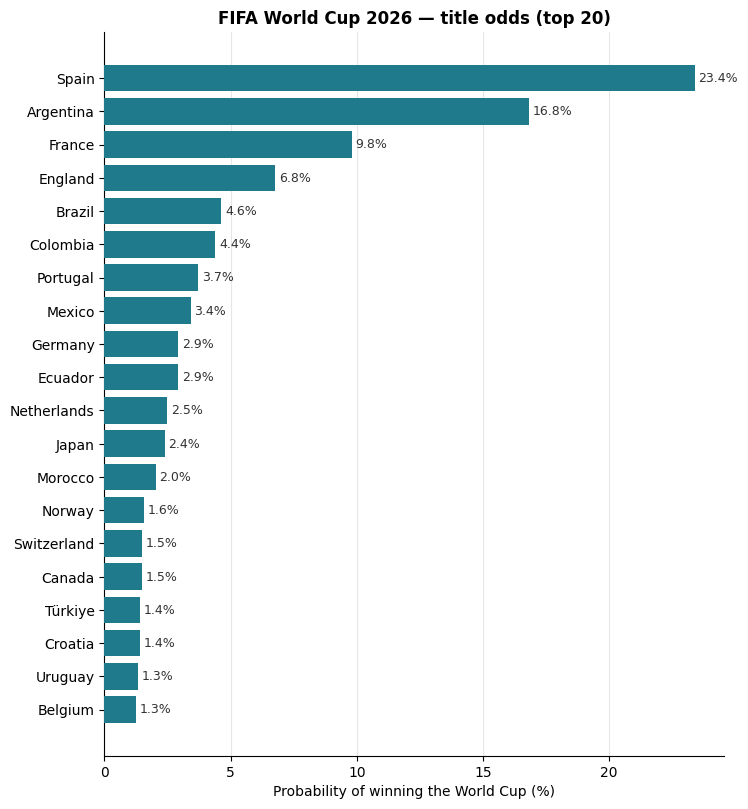

In [20]:
df = Tournament(elo, model, seed=0).simulate(50_000, seed=0)
bar_champion(df, top=20);

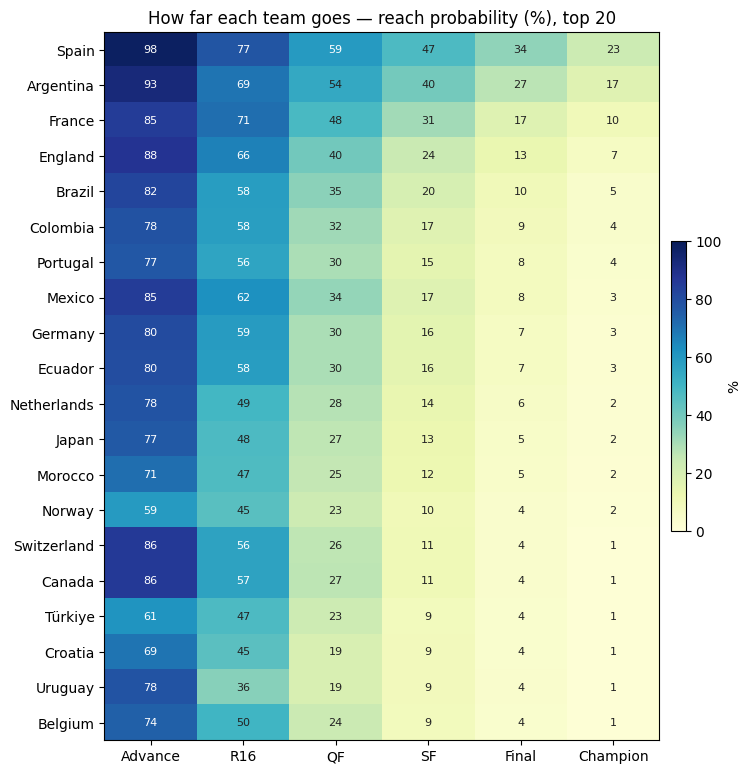

In [21]:
stage_heatmap(df, top=20);

In [23]:
cols = ["team","group","elo","advance","reach_QF","reach_SF","reach_final","champion"]
out = df[cols].copy()
for c in cols[3:]:
    out[c] = (out[c]*100).round(1)
out.head(20)

,team,group,elo,advance,reach_QF,reach_SF,reach_final,champion
0,Spain,H,2204,97.7,59.0,47.5,34.5,23.4
1,Argentina,J,2170,92.9,54.5,39.6,27.0,16.8
2,France,I,2112,85.0,48.2,31.3,17.3,9.8
3,England,L,2078,87.8,39.9,24.1,13.4,6.8
4,Brazil,C,2051,82.0,35.4,19.9,9.8,4.6
5,Colombia,K,2041,78.2,32.0,17.1,9.3,4.4
6,Portugal,K,2031,76.8,29.8,15.4,8.0,3.7
7,Mexico,A,2017,84.8,33.6,17.3,7.9,3.4
8,Germany,E,2007,80.4,29.9,15.7,6.8,2.9
9,Ecuador,E,2005,80.0,30.0,15.6,6.8,2.9


## 8 · Is it calibrated? (out-of-sample backtest)
Fit on internationals before 2022, scored on every one since (data the model never saw).
Skipped automatically if running on the offline fallback.

Out-of-sample backtest (matches since 2022-01-01, n=4,528)
  log-loss : 0.8760  (baseline 1.0505)
  Brier    : 0.5154  (baseline 0.6335)
  accuracy : 59.9%  (baseline 47.7%)
  skill vs baseline (log-loss): 16.6%


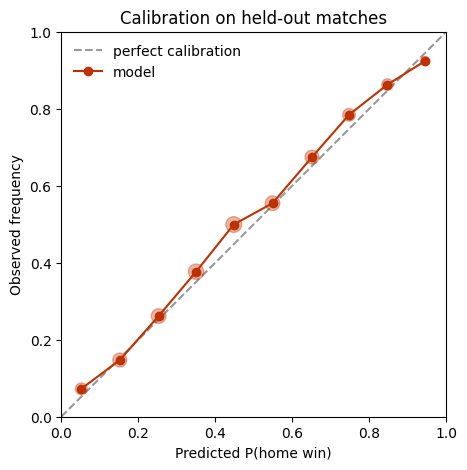

In [24]:
if results is not None:
    bt = backtest(attach_prematch_elo(results), cutoff="2022-01-01", train_since="2008-01-01")
    print(summary_text(bt))
    reliability_plot(bt["reliability"]);
else:
    print("Backtest needs the match history (currently on offline fallback) — skipped.")

## 9 · Why this team? (explainability)
Each bar re-runs the whole tournament with one thing changed, attributing the favourite's
odds to concrete causes.

,scenario,champion_pct,delta_vs_actual
0,Actual forecast,23.055,0.00
1,If team were average,0.735,-22.32
2,Team +50 Elo,31.535,8.48
3,Team +100 Elo,40.835,17.78
4,Team -100 Elo,10.525,-12.53
5,If field were average,39.645,16.59


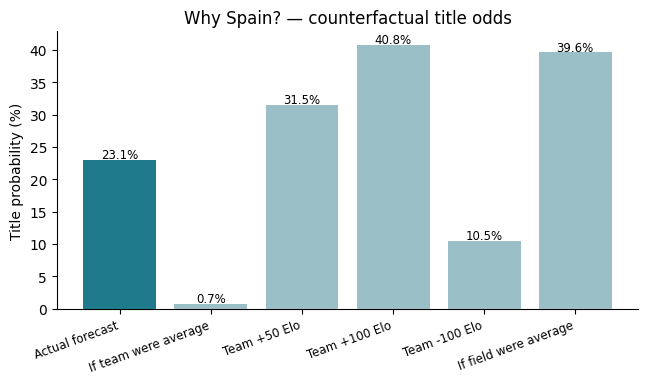

In [25]:
ex = explain_team(elo, model, "Spain", n_sims=20_000)
display(ex)
explain_chart(ex);

## 10 · What-if - force a result, watch the race move

,team,delta_pp
0,Spain,-2.56
1,Argentina,-2.17
2,France,0.66
3,England,0.64
4,Uruguay,0.56
5,Mexico,0.46
6,Brazil,0.38
7,Portugal,0.30


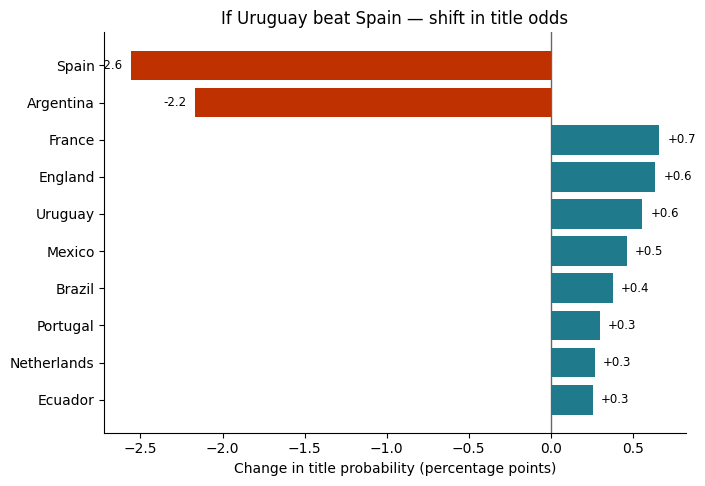

In [26]:
wi = what_if(elo, model, df, {("H", "Uruguay", "Spain"): "Uruguay"}, n_sims=20_000)
display(wi.head(8).assign(delta_pp=lambda d: (d.delta*100).round(2))[["team","delta_pp"]])
whatif_chart(wi, top=10, title="If Uruguay beat Spain — shift in title odds");

## 11 · A *living* forecast — update as matches are played

`forecast_from_state(...)` pins the matches that have **already happened** and simulates
only what's left, so the odds sharpen as the tournament unfolds. Pin results **in the order
they're played** (group games first, then knockouts):

- `group_scores` — real scorelines `{(group, teamA, teamB): (goalsA, goalsB)}`. Use the
  actual score so the group's goal-difference tiebreaker is right.
- `ko_winners` — decided knockout ties `{match_no: winner}`. Match numbers:
  **73–88** Round of 32, **89–96** Round of 16, **97–100** quarter-finals,
  **101–102** semi-finals, **104** final.

Team names accept either spelling (`"Türkiye"` or `"Turkey"`).

In [ ]:
# Example mid-tournament state — edit these as real results come in.
state = dict(
    group_scores={
        ("C", "Brazil", "Scotland"): (3, 1),   # played: Brazil win, +2 GD
        ("H", "Spain", "Cape Verde"): (2, 0),
        ("L", "England", "Croatia"): (1, 1),    # played: draw
    },
    ko_winners={
        # add ties as the knockouts begin, e.g. 84: "Spain", 73: "Switzerland"
    },
)
live = forecast_from_state(elo, model, n_sims=50_000, **state)
display(live.head(12)[["team", "group", "champion"]]
        .assign(champion=lambda d: (d.champion * 100).round(1)))
bar_champion(live, top=16);

When every match is pinned, the probabilities collapse to a single outcome  that's the
forecast turning into the result. Until then you get an honest, continuously-updated read on
who's most likely to lift the trophy.

*Forecasts are illustrative football is gloriously unpredictable, which is the point of
putting calibrated probabilities on it.*